# Support Vector Machines

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from scipy import stats

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X, Y = make_blobs(n_samples = 50, centers = 2, random_state = 0, cluster_std = 0.6)

In [4]:
X

array([[ 1.41281595,  1.5303347 ],
       [ 1.81336135,  1.6311307 ],
       [ 1.43289271,  4.37679234],
       [ 1.87271752,  4.18069237],
       [ 2.09517785,  1.0791468 ],
       [ 2.73890793,  0.15676817],
       [ 3.18515794,  0.08900822],
       [ 2.06156753,  1.96918596],
       [ 2.03835818,  1.15466278],
       [-0.04749204,  5.47425256],
       [ 1.71444449,  5.02521524],
       [ 0.22459286,  4.77028154],
       [ 1.06923853,  4.53068484],
       [ 1.53278923,  0.55035386],
       [ 1.4949318 ,  3.85848832],
       [ 1.1641107 ,  3.79132988],
       [ 0.74387399,  4.12240568],
       [ 2.29667251,  0.48677761],
       [ 0.44359863,  3.11530945],
       [ 0.91433877,  4.55014643],
       [ 1.67467427,  0.68001896],
       [ 2.26908736,  1.32160756],
       [ 1.5108885 ,  0.9288309 ],
       [ 1.65179125,  0.68193176],
       [ 2.49272186,  0.97505341],
       [ 2.33812285,  3.43116792],
       [ 0.67047877,  4.04094275],
       [-0.55552381,  4.69595848],
       [ 2.16172321,

In [5]:
Y

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0])

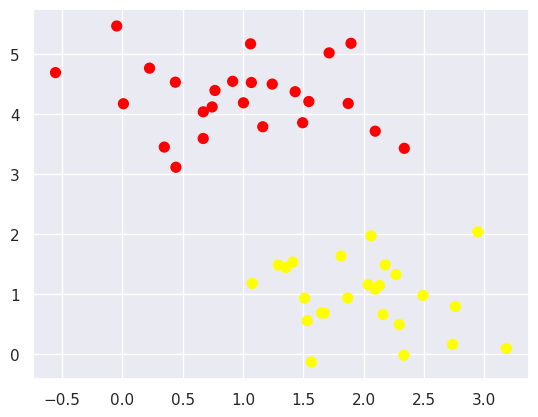

In [6]:
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')

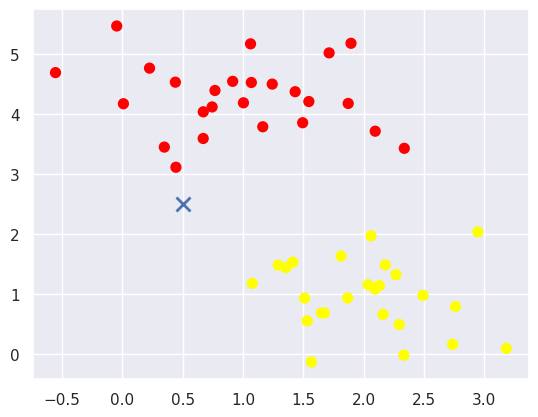

In [7]:
xx = np.linspace(-1, 3.5)
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
plt.plot([0.5], [2.5], 'x', markeredgewidth = 2, markersize = 10)

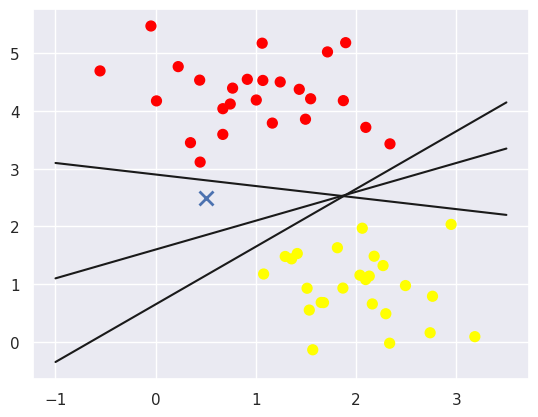

In [8]:
xx = np.linspace(-1, 3.5)
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
plt.plot([0.5], [2.5], 'x', markeredgewidth = 2, markersize = 10)

for a, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    yy = a * xx + b
    plt.plot(xx, yy, 'k-')

(-1.0, 3.5)

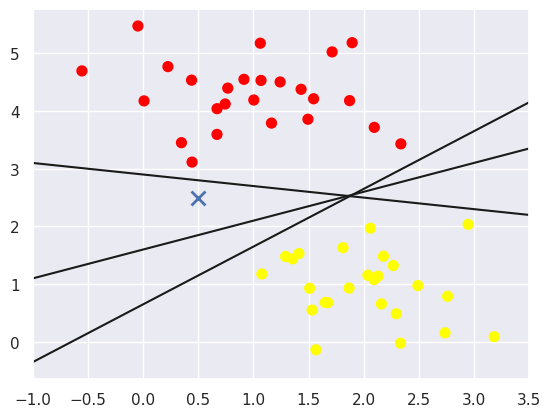

In [9]:
xx = np.linspace(-1, 3.5)
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
plt.plot([0.5], [2.5], 'x', markeredgewidth = 2, markersize = 10)

for a, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    yy = a * xx + b
    plt.plot(xx, yy, 'k-')

plt.xlim(-1, 3.5)

(-1.0, 3.5)

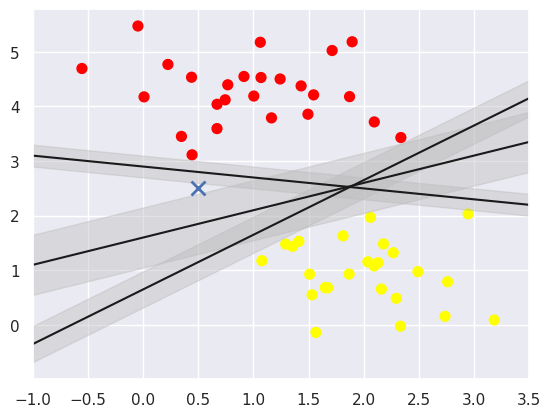

In [10]:
xx = np.linspace(-1, 3.5)
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
plt.plot([0.5], [2.5], 'x', markeredgewidth = 2, markersize = 10)

for a, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yy = a * xx + b
    plt.plot(xx, yy, 'k-')
    plt.fill_between(xx, yy - d, yy + d,
                     edgecolor = 'none',
                     color = '#BBBBBB', alpha = 0.4
                     )

plt.xlim(-1, 3.5)

# Creación del modelo SVM.

In [11]:
from sklearn.svm import SVC

In [12]:
model = SVC(kernel = 'linear', C = 1E10)
model.fit(X, Y)

SVC(C=10000000000.0, kernel='linear')

In [13]:
def plt_svc(model, ax = None, plot_support = True):
    if ax == None:
        ax = plt.gca()

    # Plot de la función de decisión para una clasificación en 2D con SVC

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Generamos la parrilla de puntos para evaluar el modelo:

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(yy, xx)

    # Evaluar el modelo:

    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # Representamos las frontereas y los márgenes del SVC

    ax.contour(X, Y, P, colors = 'k', levels = [-1, 0, 1],
               alpha = 0.5, linestyles = ['--', '-', '--']
               )

    print(model.support_vectors_)

    if plot_support == True:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s = 300, linewidth = 1, facecolors = 'black'
                   )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

[[0.44359863 3.11530945]
 [2.33812285 3.43116792]
 [2.06156753 1.96918596]]


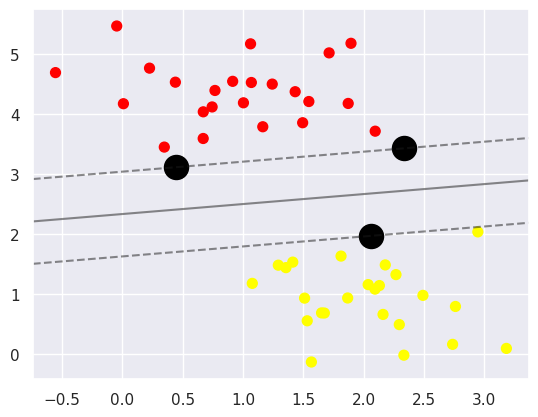

In [14]:
plt.scatter(X[:,0], X[:,1], c = Y, s = 50, cmap = 'autumn')
plt_svc(model)

In [19]:
def plot_svm(N = 10, ax = None):
    X, Y = make_blobs(n_samples = 200, centers = 2,
                      random_state = 0, cluster_std = 0.6
                      )

    X = X[: N]
    Y = Y[: N]

    model = SVC(kernel = 'linear', C = 1E10)
    model.fit(X, Y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plt_svc(model, ax)

[[0.44359863 3.11530945]
 [1.25566754 3.38204112]
 [0.83685684 2.13635938]]
[[0.44359863 3.11530945]
 [1.25566754 3.38204112]
 [0.83685684 2.13635938]]


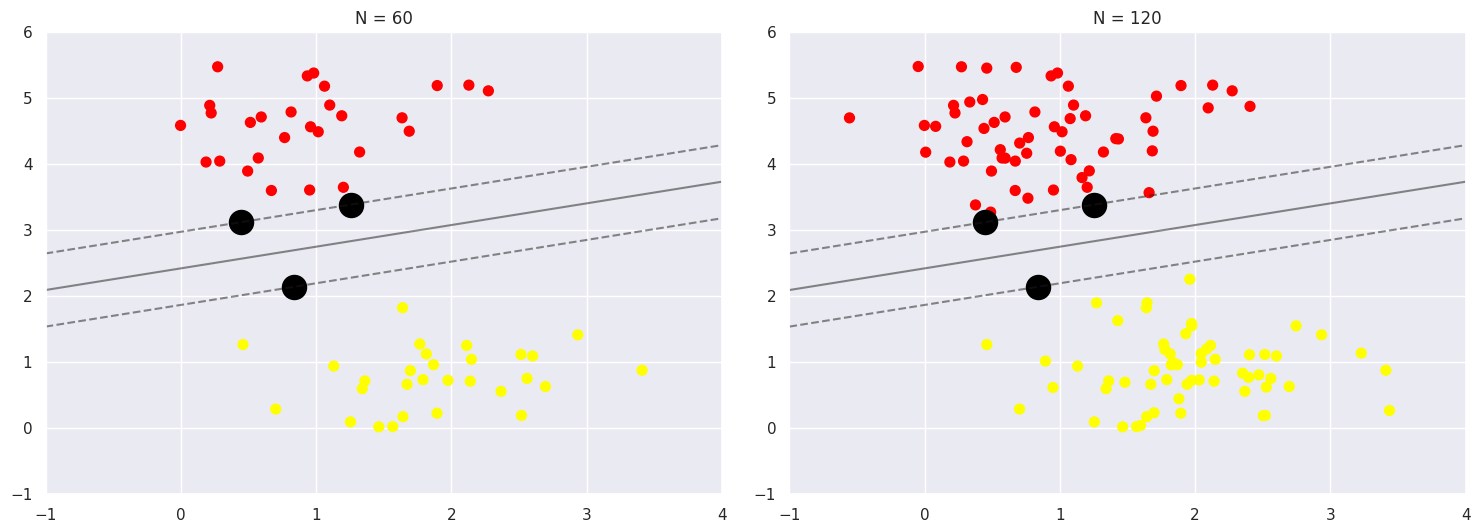

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
fig.subplots_adjust(left = 0.0625, right = 0.95, wspace = 0.1)

for ax_i, N in zip(ax, [60, 120]):
    plot_svm(N, ax_i)
    ax_i.set_title('N = {}'.format(N))

In [21]:
from ipywidgets import interact, fixed

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

<function __main__.plot_svm(N=10, ax=None)>

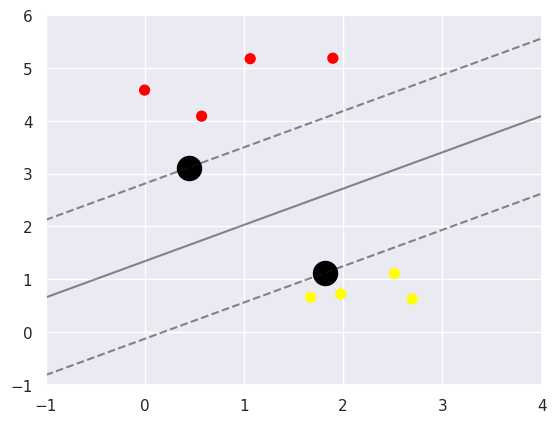

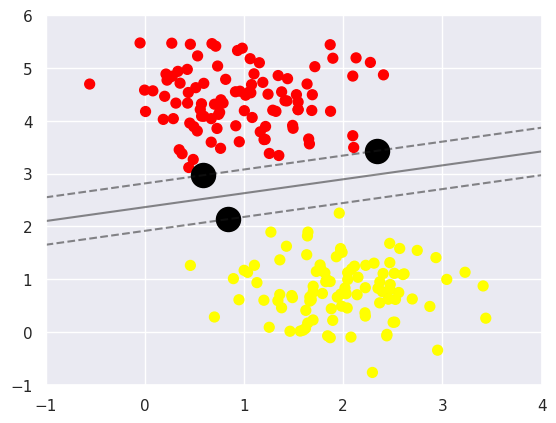

In [23]:
interact(plot_svm, N = [10, 200], ax = fixed(None))